## Make sure the packages are installed

In [18]:
import subprocess
subprocess.run(['pip', 'install', 'seaborn', 'matplotlib', 
                'pandas', 'scikit-learn', 'prophet'], 
               capture_output=True)
print("All packages installed")

All packages installed


## Step 1: Load and explore the data

Before cleaning anything, we first profile the dataset to understand:
- What columns exist and their data types
- Where nulls are concentrated
- The cardinality (unique values) of each column
- Basic distribution of key operational fields

This exploration is what drives the cleaning decisions. We don't just drop columns,
we drop them because the data profile shows if they have any value for our analysis.

In [22]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# load raw dataset: requires latin-1 encoding (not UTF-8)
df_raw = pd.read_csv(r'C:\Users\cueva\Downloads\DataCoSupplyChainDataset.csv', 
    encoding='latin-1')
print("=" * 50)
print("RAW DATASET PROFILE")
print("=" * 50)
print(f"Rows:    {df_raw.shape[0]:,}")
print(f"Columns: {df_raw.shape[1]}")
print(f"Memory:  {df_raw.memory_usage(deep=True).sum() / 1024**2:.1f} MB")

RAW DATASET PROFILE
Rows:    180,519
Columns: 53
Memory:  298.9 MB


### Data types and column overview

In [23]:
# Show all column names, data types, and non-null counts
print(df_raw.dtypes.to_string())
print()
print(f"Total non-null values per column:")
print(df_raw.count().to_string())

Type                                 str
Days for shipping (real)           int64
Days for shipment (scheduled)      int64
Benefit per order                float64
Sales per customer               float64
Delivery Status                      str
Late_delivery_risk                 int64
Category Id                        int64
Category Name                        str
Customer City                        str
Customer Country                     str
Customer Email                       str
Customer Fname                       str
Customer Id                        int64
Customer Lname                       str
Customer Password                    str
Customer Segment                     str
Customer State                       str
Customer Street                      str
Customer Zipcode                 float64
Department Id                      int64
Department Name                      str
Latitude                         float64
Longitude                        float64
Market          

### Null Analysis

One of the most important profiling step. Columns with high null rates are prime candidates for removal.
A column that is mostly null provides 0 analytical value and takes too much space in such a larger file.

Columns with nulls:
                     Null Count  Null %
Product Description      180519  100.00
Order Zipcode            155679   86.24
Customer Lname                8    0.00
Customer Zipcode              3    0.00

Columns with zero nulls: 49



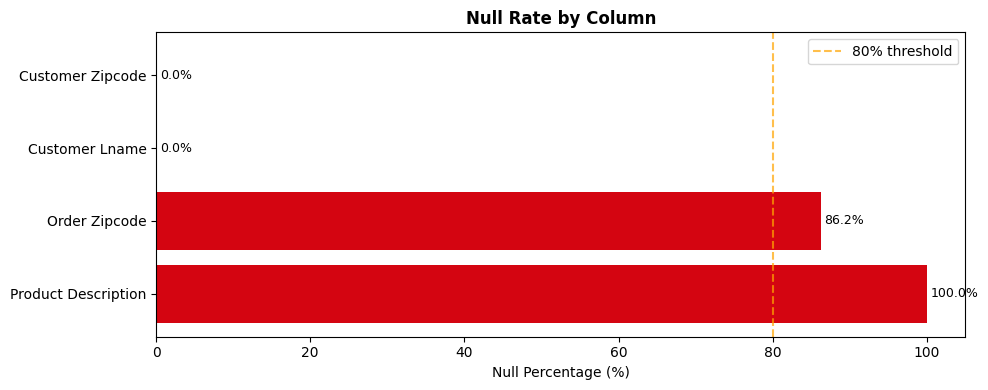

In [25]:
# calculate null count and percentage for every column
null_counts = df_raw.isnull().sum()
null_pct    = (null_counts / len(df_raw) * 100).round(2)

null_df = pd.DataFrame({
    'Null Count': null_counts,
    'Null %':     null_pct
}).sort_values('Null %', ascending=False)

# show only columns that have at least one null
null_df_filtered = null_df[null_df['Null Count'] > 0]
print("Columns with nulls:")
print(null_df_filtered.to_string())
print()
print(f"Columns with zero nulls: {(null_df['Null Count'] == 0).sum()}")
print()

# visualize null distribution
if len(null_df_filtered) > 0:
    fig, ax = plt.subplots(figsize=(10, 4))
    bars = ax.barh(null_df_filtered.index, null_df_filtered['Null %'], color='#D40511')
    ax.set_xlabel('Null Percentage (%)')
    ax.set_title('Null Rate by Column', fontweight='bold')
    ax.axvline(x=80, color='orange', linestyle='--', alpha=0.7, label='80% threshold')
    ax.legend()
    for bar, val in zip(bars, null_df_filtered['Null %']):
        ax.text(bar.get_width() + 0.5, bar.get_y() + bar.get_height()/2,
                f'{val:.1f}%', va='center', fontsize=9)
    plt.tight_layout()
    plt.savefig('null_analysis.png', dpi=150, bbox_inches='tight')
    plt.show()

## Dropped columns conclusion

Order Zipcode and Product description offer no analytical values. They will be dropped when we go through the data manipulation section.

### Cardinality Analysis

Columns with only one unique value have zero variation. They cannot distinguish
any orders from each other and also don't provide analytical value.

In [26]:
# count unique values per column to reveal low-cardinality columns
cardinality = df_raw.nunique().sort_values()

print("Columns with very low cardinality (potential drops):")
low_card = cardinality[cardinality <= 5]
for col, n in low_card.items():
    unique_vals = df_raw[col].unique()[:5]
    print(f"  {col}: {n} unique value(s) → {unique_vals}")

print()
print("Columns with high cardinality (useful for analysis):")
high_card = cardinality[cardinality > 100].tail(10)
print(high_card.to_string())

Columns with very low cardinality (potential drops):
  Product Description: 0 unique value(s) → [nan]
  Customer Password: 1 unique value(s) → <StringArray>
['XXXXXXXXX']
Length: 1, dtype: str
  Product Status: 1 unique value(s) → [0]
  Customer Email: 1 unique value(s) → <StringArray>
['XXXXXXXXX']
Length: 1, dtype: str
  Late_delivery_risk: 2 unique value(s) → [0 1]
  Customer Country: 2 unique value(s) → <StringArray>
['Puerto Rico', 'EE. UU.']
Length: 2, dtype: str
  Customer Segment: 3 unique value(s) → <StringArray>
['Consumer', 'Home Office', 'Corporate']
Length: 3, dtype: str
  Delivery Status: 4 unique value(s) → <StringArray>
['Advance shipping', 'Late delivery', 'Shipping on time', 'Shipping canceled']
Length: 4, dtype: str
  Days for shipment (scheduled): 4 unique value(s) → [4 1 2 0]
  Shipping Mode: 4 unique value(s) → <StringArray>
['Standard Class', 'First Class', 'Second Class', 'Same Day']
Length: 4, dtype: str
  Type: 4 unique value(s) → <StringArray>
['DEBIT', 'TRAN

### Market Distribution

The dataset covers global markets. We need to understand the market breakdown
before filtering to the U.S. and Canada, the operationally relevant subset
for DHL's North American distribution network.

Market Distribution:
  LATAM       51,594 orders  (28.6%)
  Europe      50,252 orders  (27.8%)
  Pacific Asia  41,260 orders  (22.9%)
  USCA        25,799 orders  (14.3%)
  Africa      11,614 orders  (6.4%)

USCA orders available for analysis: 25,799
This represents 14.3% of the full dataset


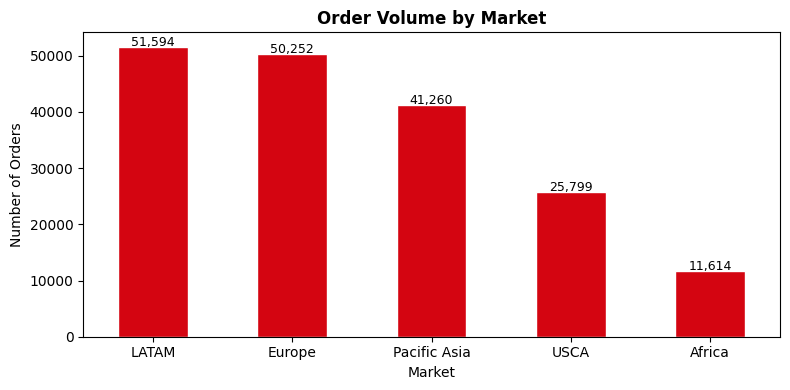

In [27]:
# market breakdown
print("Market Distribution:")
market_counts = df_raw['Market'].value_counts()
market_pcts   = (market_counts / len(df_raw) * 100).round(1)

for market, count in market_counts.items():
    print(f"  {market:<10} {count:>7,} orders  ({market_pcts[market]:.1f}%)")

print()
print(f"USCA orders available for analysis: {(df_raw['Market'] == 'USCA').sum():,}")
print(f"This represents {(df_raw['Market'] == 'USCA').mean():.1%} of the full dataset")

# visualize
fig, ax = plt.subplots(figsize=(8, 4))
market_counts.plot(kind='bar', ax=ax, color='#D40511', edgecolor='white')
ax.set_title('Order Volume by Market', fontweight='bold')
ax.set_ylabel('Number of Orders')
ax.set_xlabel('Market')
ax.tick_params(axis='x', rotation=0)
for bar in ax.patches:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 200,
            f'{int(bar.get_height()):,}', ha='center', fontsize=9)
plt.tight_layout()
plt.show()

### Key operational fields: initial distribution

Before we start cleaning, we explore the key fields that will drive our analysis:
- Delivery status and late delivery risk
- Shipping mode distribution
- Days for shipping: actual vs scheduled

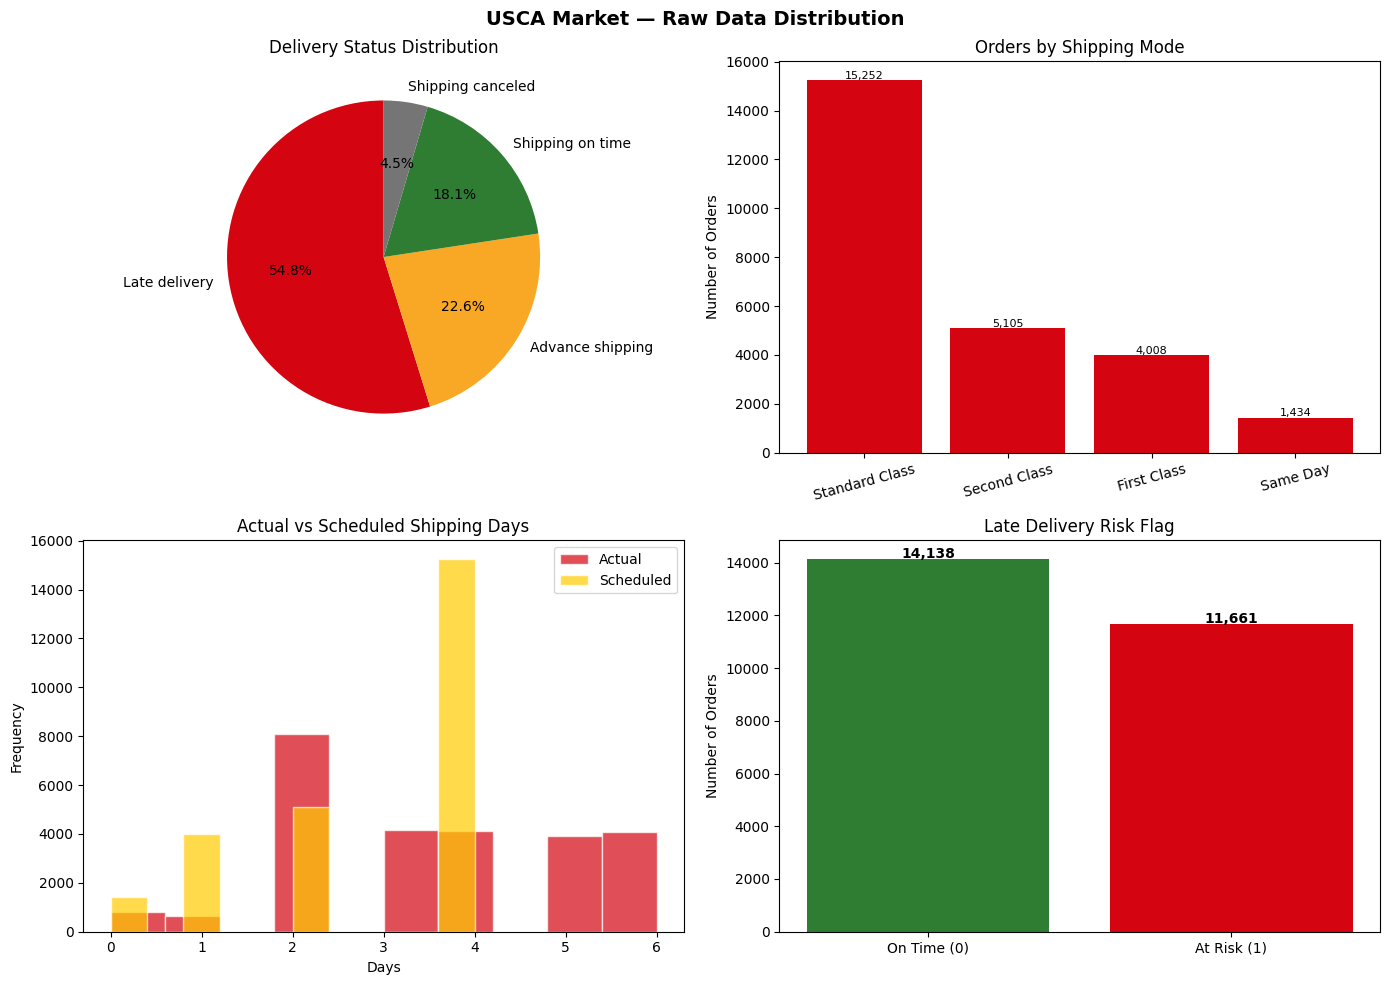

Initial late delivery rate (raw): 54.8%


In [29]:
# focus on USCA market for operational analysis
df_usca_raw = df_raw[df_raw['Market'] == 'USCA'].copy()

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('USCA Market — Raw Data Distribution', fontsize=14, fontweight='bold')

# delivery Status
delivery_counts = df_usca_raw['Delivery Status'].value_counts()
colors_pie = ['#D40511', '#F9A825', '#2E7D32', '#757575']
axes[0,0].pie(delivery_counts.values, labels=delivery_counts.index,
              colors=colors_pie[:len(delivery_counts)],
              autopct='%1.1f%%', startangle=90)
axes[0,0].set_title('Delivery Status Distribution')

# shipping Mode
mode_counts = df_usca_raw['Shipping Mode'].value_counts()
axes[0,1].bar(mode_counts.index, mode_counts.values, color='#D40511')
axes[0,1].set_title('Orders by Shipping Mode')
axes[0,1].set_ylabel('Number of Orders')
axes[0,1].tick_params(axis='x', rotation=15)
for bar in axes[0,1].patches:
    axes[0,1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 50,
                   f'{int(bar.get_height()):,}', ha='center', fontsize=8)

# actual vs Scheduled Shipping Days
axes[1,0].hist(df_usca_raw['Days for shipping (real)'].dropna(),
               bins=10, color='#D40511', alpha=0.7, label='Actual', edgecolor='white')
axes[1,0].hist(df_usca_raw['Days for shipment (scheduled)'].dropna(),
               bins=10, color='#FFCC00', alpha=0.7, label='Scheduled', edgecolor='white')
axes[1,0].set_title('Actual vs Scheduled Shipping Days')
axes[1,0].set_xlabel('Days')
axes[1,0].set_ylabel('Frequency')
axes[1,0].legend()

# late delivery risk
late_counts = df_usca_raw['Late_delivery_risk'].value_counts()
axes[1,1].bar(['On Time (0)', 'At Risk (1)'], late_counts.values,
               color=['#2E7D32', '#D40511'])
axes[1,1].set_title('Late Delivery Risk Flag')
axes[1,1].set_ylabel('Number of Orders')
for bar in axes[1,1].patches:
    axes[1,1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 50,
                   f'{int(bar.get_height()):,}', ha='center', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.savefig('raw_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"Initial late delivery rate (raw): {df_usca_raw['Late_delivery_risk'].mean():.1%}")

### Order region distribution (facility assignment preview)

The dataset uses 'Order Region' not facility names. We preview the USCA regions
to understand how we will assign orders to the two distribution centers.

In [ ]:
# USCA region breakdown, drives facility assignment decision
print("USCA Order Region Breakdown:")
region_counts = df_usca_raw['Order Region'].value_counts()
for region, count in region_counts.items():
    pct = count / len(df_usca_raw) * 100
    print(f"  {region:<20} {count:>5,} orders  ({pct:.1f}%)")

print()
print("Facility Assignment Logic:")
print("  'South of USA'  → Jacksonville DC (FL) — Southeast hub")
print("  'East of USA'   → Bethlehem DC (PA)    — Northeast hub")
print("  All others      → Excluded from two-facility analysis")
print()

# show which states appear in each key region
for region in ['South of  USA', 'East of USA']:
    if region in df_usca_raw['Order Region'].values:
        states = df_usca_raw[df_usca_raw['Order Region']==region]['Customer State'].value_counts().head(5)
        print(f"Top states in '{region}':")
        print(states.to_string())
        print()

USCA Order Region Breakdown:
  West of USA          7,993 orders  (31.0%)
  East of USA          6,915 orders  (26.8%)
  US Center            5,887 orders  (22.8%)
  South of  USA        4,045 orders  (15.7%)
  Canada                 959 orders  (3.7%)

Facility Assignment Logic:
  'South of USA'  → Jacksonville DC (FL) — Southeast hub
  'East of USA'   → Bethlehem DC (PA)    — Northeast hub
  All others      → Excluded from two-facility analysis

Top states in 'East of USA':
Customer State
PR    2640
CA    1059
NY     418
IL     357
TX     340



## Note: CA in the East region

Customer state doesn't accurately map to order region. Facility assignment uses routing region, which is the operationally correct appoach.

## Step 2 — Data Cleaning

Based on the EDA above, we now clean with specific justification for each decision:

| Decision | Justification from EDA |
|----------|------------------------|
| Drop Product Description | 100% null: confirmed in null analysis |
| Drop Order Zipcode | 86% null: confirmed in null analysis |
| Drop Customer Email/Password | Sensitive, 1 unique value confirmed in cardinality analysis and no analytical value for the business problem |
| Drop Product Image/Status | URLs only / 1 unique value confirmed in cardinality analysis, again no analytical value |
| Fix date columns | Stored as strings: cannot sort or filter by time without conversion |
| Engineer Fulfillment Gap | Actual - Scheduled shows systematic lateness pattern |
| Filter to USCA | 6% of data — operationally relevant to North American DC context |
| Assign facilities by region | South → Jacksonville, East → Bethlehem based on geographic mapping, chose these locations based on DHL's real operations with Primark |

## Clean, engineer, and filter

In [1]:
import pandas as pd

# load with latin-1 encoding
df = pd.read_csv(r'C:\Users\cueva\Downloads\DataCoSupplyChainDataset.csv', encoding='latin-1')

print(f"Original shape: {df.shape}")

# drop useless columns
cols_to_drop = [
    'Product Description',  # 100% null
    'Order Zipcode',        # 86% null
    'Customer Email',       # Only 1 unique value
    'Customer Password',    # Sensitive, no value
    'Product Image',        # URLs only
    'Product Status'        # Only 1 unique value
]
df = df.drop(columns=cols_to_drop)
print(f"After dropping useless columns: {df.shape}")

# fix nulls
df['Customer Lname'] = df['Customer Lname'].fillna('Unknown')
df['Customer Zipcode'] = df['Customer Zipcode'].fillna(0)
print(f"Nulls remaining: {df.isnull().sum().sum()}")

# fix date columns
df['Order Date'] = pd.to_datetime(
    df['order date (DateOrders)'],
    format='%m/%d/%Y %H:%M'
)
df['Shipping Date'] = pd.to_datetime(
    df['shipping date (DateOrders)'],
    format='%m/%d/%Y %H:%M'
)

# engineer useful columns
df['Order Year'] = df['Order Date'].dt.year
df['Order Month'] = df['Order Date'].dt.month
df['Order Month Name'] = df['Order Date'].dt.strftime('%b')
df['Order Quarter'] = df['Order Date'].dt.quarter
df['Fulfillment Gap'] = (
    df['Days for shipping (real)'] -
    df['Days for shipment (scheduled)']
)
df['Is Late'] = (df['Late_delivery_risk'] == 1).astype(int)
df['On Time'] = (df['Late_delivery_risk'] == 0).astype(int)

# filter to USCA market
df_usca = df[df['Market'] == 'USCA'].copy()
print(f"\nUSCA orders: {len(df_usca):,}")

# create two facility groups
def assign_facility(region):
    if 'South' in str(region):
        return 'Jacksonville DC (FL)'
    elif 'East' in str(region):
        return 'Bethlehem DC (PA)'
    else:
        return 'Other'

df_usca['Facility'] = df_usca['Order Region'].apply(assign_facility)

# filter to just the two main facilities
df_two_sites = df_usca[
    df_usca['Facility'] != 'Other'
].copy()

print(f"\nFacility breakdown:")
print(df_two_sites['Facility'].value_counts())
print(f"\nLate delivery rate overall: {df_two_sites['Is Late'].mean():.1%}")
print(f"\nLate delivery by facility:")
print(df_two_sites.groupby('Facility')['Is Late'].mean().round(3))

# save cleaned csv for Power BI
df_two_sites.to_csv('DataCo_Cleaned.csv', index=False)
print(f"Cleaned dataset saved: {len(df_two_sites):,} rows")

Original shape: (180519, 53)
After dropping useless columns: (180519, 47)
Nulls remaining: 0

USCA orders: 25,799

Facility breakdown:
Facility
Bethlehem DC (PA)       6915
Jacksonville DC (FL)    4045
Name: count, dtype: int64

Late delivery rate overall: 55.7%

Late delivery by facility:
Facility
Bethlehem DC (PA)       0.557
Jacksonville DC (FL)    0.558
Name: Is Late, dtype: float64
Cleaned dataset saved: 10,960 rows


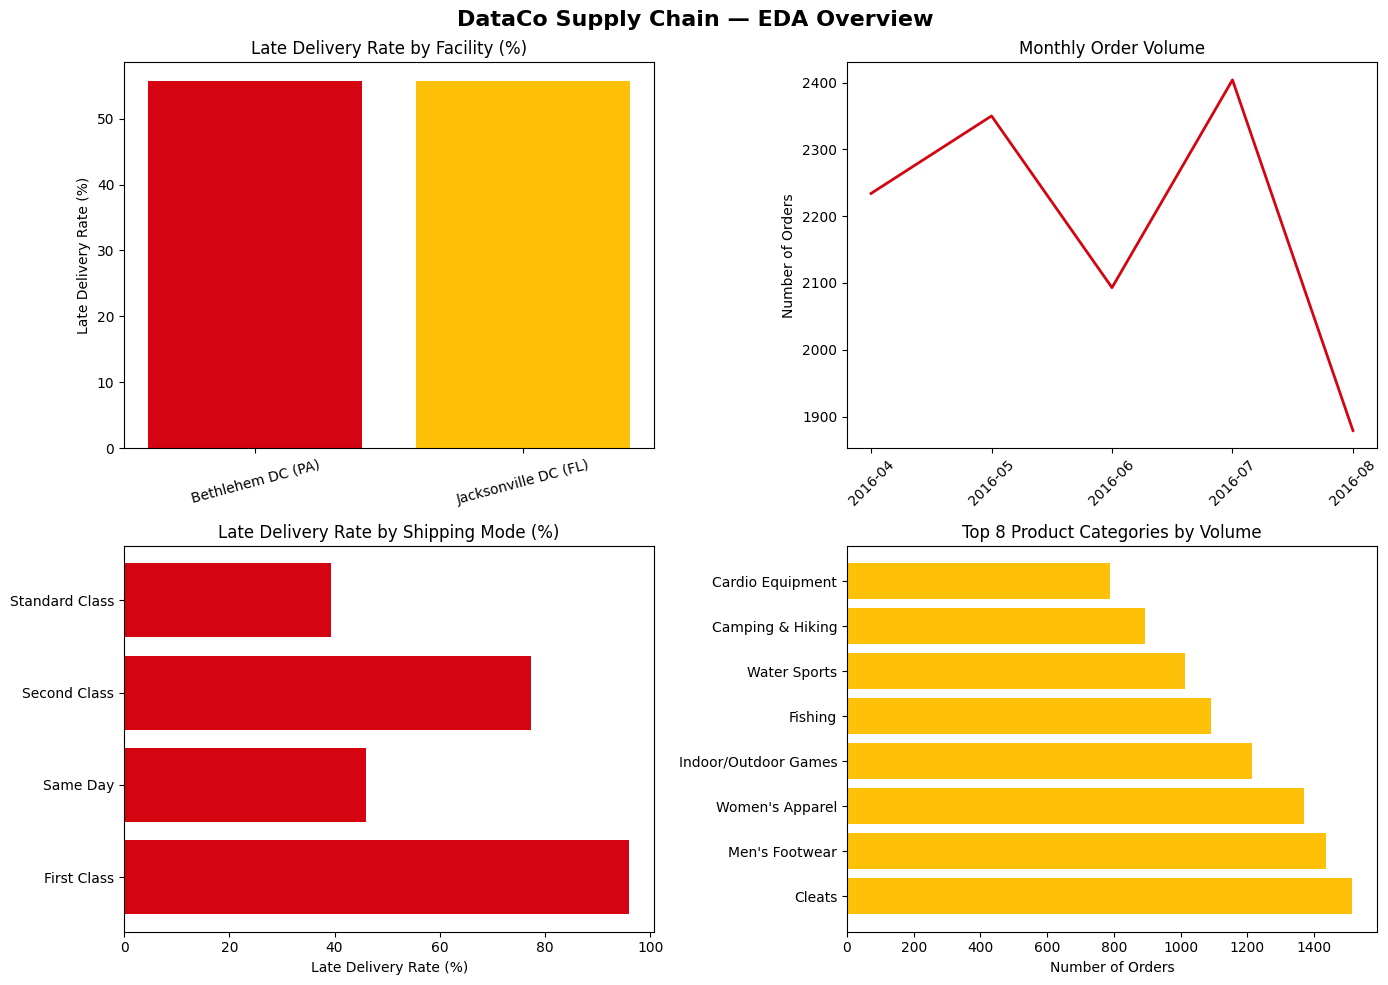

EDA chart saved


In [2]:
import matplotlib.pyplot as plt
import seaborn as sns

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('DataCo Supply Chain — EDA Overview', fontsize=16, fontweight='bold')

# late delivery by facility
facility_late = df_two_sites.groupby('Facility')['Is Late'].mean().reset_index()
axes[0,0].bar(facility_late['Facility'],
              facility_late['Is Late'] * 100,
              color=['#D40511', '#FFC107'])
axes[0,0].set_title('Late Delivery Rate by Facility (%)')
axes[0,0].set_ylabel('Late Delivery Rate (%)')
axes[0,0].tick_params(axis='x', rotation=15)

# orders by month
monthly = df_two_sites.groupby(['Order Year', 'Order Month']).size().reset_index(name='Orders')
monthly['Period'] = monthly['Order Year'].astype(str) + '-' + monthly['Order Month'].astype(str).str.zfill(2)
axes[0,1].plot(monthly['Period'], monthly['Orders'], color='#D40511', linewidth=2)
axes[0,1].set_title('Monthly Order Volume')
axes[0,1].set_ylabel('Number of Orders')
axes[0,1].tick_params(axis='x', rotation=45)

# late delivery by shipping mode
shipping_late = df_two_sites.groupby('Shipping Mode')['Is Late'].mean().reset_index()
axes[1,0].barh(shipping_late['Shipping Mode'],
               shipping_late['Is Late'] * 100,
               color='#D40511')
axes[1,0].set_title('Late Delivery Rate by Shipping Mode (%)')
axes[1,0].set_xlabel('Late Delivery Rate (%)')

# top categories by volume
top_cats = df_two_sites['Category Name'].value_counts().head(8)
axes[1,1].barh(top_cats.index, top_cats.values, color='#FFC107')
axes[1,1].set_title('Top 8 Product Categories by Volume')
axes[1,1].set_xlabel('Number of Orders')

plt.tight_layout()
plt.savefig('eda_overview.png', dpi=150, bbox_inches='tight')
plt.show()
print("EDA chart saved")

21:46:26 - cmdstanpy - INFO - Chain [1] start processing
21:46:26 - cmdstanpy - INFO - Chain [1] done processing


Time series: 147 days of data
Date range: 2016-04-01 00:00:00 to 2016-08-25 00:00:00


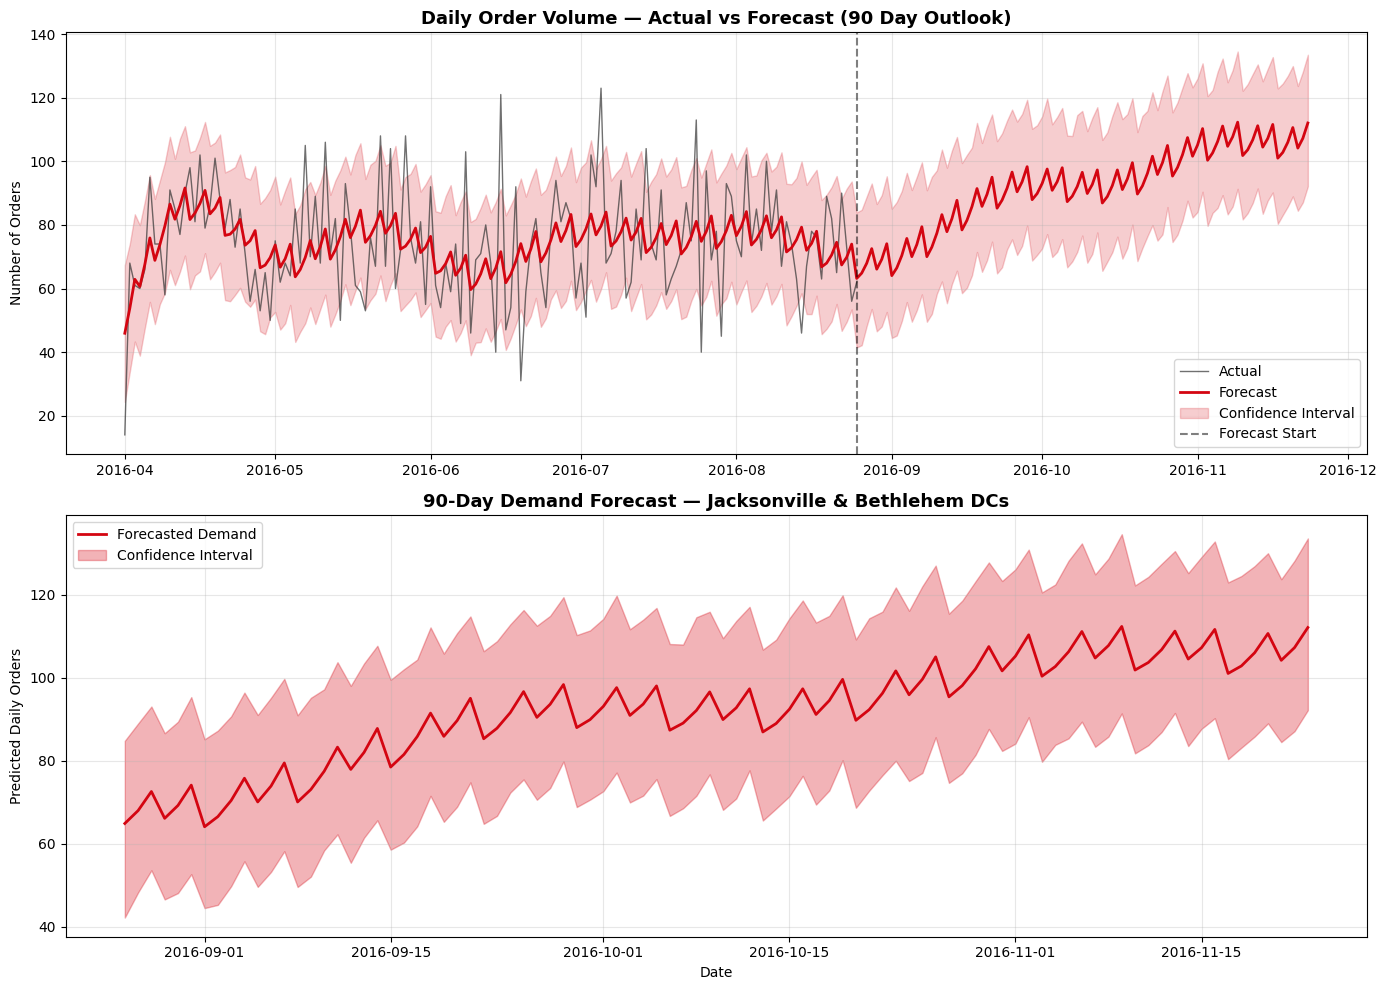


Forecast Accuracy:
MAE:  12.4 orders/day
MAPE: 19.2%

90-Day Forecast Summary:
Average daily orders: 92
Peak day forecast:    112
Low day forecast:     64
Demand growth:        23.7%


In [4]:
from prophet import Prophet
import pandas as pd
import matplotlib.pyplot as plt

# prepare time series
daily_orders = df_two_sites.groupby(
    df_two_sites['Order Date'].dt.date
).size().reset_index()
daily_orders.columns = ['ds', 'y']
daily_orders['ds'] = pd.to_datetime(daily_orders['ds'])

print(f"Time series: {len(daily_orders)} days of data")
print(f"Date range: {daily_orders['ds'].min()} to {daily_orders['ds'].max()}")

# build and fit model
model = Prophet(
    yearly_seasonality=True,
    weekly_seasonality=True,
    daily_seasonality=False,
    changepoint_prior_scale=0.05
)
model.fit(daily_orders)

# forecast 90 days
future   = model.make_future_dataframe(periods=90)
forecast = model.predict(future)

# plot 
fig, axes = plt.subplots(2, 1, figsize=(14, 10))

# plot 1: actual vs forecast
axes[0].plot(daily_orders['ds'], daily_orders['y'],
             color='#333333', linewidth=1, label='Actual', alpha=0.7)
axes[0].plot(forecast['ds'], forecast['yhat'],
             color='#D40511', linewidth=2, label='Forecast')
axes[0].fill_between(forecast['ds'],
                     forecast['yhat_lower'],
                     forecast['yhat_upper'],
                     alpha=0.2, color='#D40511', label='Confidence Interval')
axes[0].axvline(x=daily_orders['ds'].max(),
                color='black', linestyle='--', alpha=0.5, label='Forecast Start')
axes[0].set_title('Daily Order Volume — Actual vs Forecast (90 Day Outlook)',
                  fontsize=13, fontweight='bold')
axes[0].set_ylabel('Number of Orders')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# plot 2: next 90 days only
future_only = forecast[forecast['ds'] > daily_orders['ds'].max()]
axes[1].plot(future_only['ds'], future_only['yhat'],
             color='#D40511', linewidth=2, label='Forecasted Demand')
axes[1].fill_between(future_only['ds'],
                     future_only['yhat_lower'],
                     future_only['yhat_upper'],
                     alpha=0.3, color='#D40511', label='Confidence Interval')
axes[1].set_title('90-Day Demand Forecast — Jacksonville & Bethlehem DCs',
                  fontsize=13, fontweight='bold')
axes[1].set_ylabel('Predicted Daily Orders')
axes[1].set_xlabel('Date')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('demand_forecast.png', dpi=150, bbox_inches='tight')
plt.show()

# accuracy metrics 
import math

actual_vals    = daily_orders['y'].tolist()
predicted_vals = forecast[forecast['ds'].isin(daily_orders['ds'])]['yhat'].tolist()

# mean absolute error
mae = sum(abs(a - p) for a, p in zip(actual_vals, predicted_vals)) / len(actual_vals)

# mean absolute percentage error
mape = sum(abs((a - p) / a) for a, p in zip(actual_vals, predicted_vals)
           if a != 0) / len(actual_vals)

print(f"\nForecast Accuracy:")
print(f"MAE:  {mae:.1f} orders/day")
print(f"MAPE: {mape:.1%}")

print(f"\n90-Day Forecast Summary:")
print(f"Average daily orders: {future_only['yhat'].mean():.0f}")
print(f"Peak day forecast:    {future_only['yhat'].max():.0f}")
print(f"Low day forecast:     {future_only['yhat'].min():.0f}")
print(f"Demand growth:        {((future_only['yhat'].mean() / daily_orders['y'].mean()) - 1):.1%}")